<a href="https://colab.research.google.com/github/Nkengfack/Bank_marketing_ml_Classifications/blob/main/bank_marketing_ML_perfomance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Term Deposit Subscription Prediction
## A Comparative Performance Analysis of Machine Learning Models

MSc Data Science Final Project, University of Hertfordshire, Module 7PAM2002.

Part 1 covers the data work behind Section 3 of the report: loading and
inspecting the UCI Bank Marketing dataset, finding the hidden missing values,
resolving the pdays anomaly, and exploring the distributions that shape the
modelling decisions in Part 2.

## 3.1 Libraries and display settings



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# One colour per outcome, reused across every chart
COLOUR_NO  = '#378ADD'   # did not subscribe
COLOUR_YES = '#D85A30'   # subscribed
PALETTE    = [COLOUR_NO, COLOUR_YES]

# The UCI target column is renamed to this on load
TARGET = 'subscribed'

## 3.2 Loading the data

The dataset is read straight from the project GitHub repository so the
notebook runs on any machine. The file uses a semicolon separator, without
sep=';' all 21 columns collapse into one. The assertion checks the shape
against the published size of the dataset (Moro et al., 2014), so if the
source file ever changes the notebook stops here instead of producing
quietly wrong results downstream.

In [ ]:
URL = ('https://raw.githubusercontent.com/Nkengfack/'
       'Bank_marketing_ml_Classifications/refs/heads/main/'
       'bank_marketing_dataset.csv')

marketing = pd.read_csv(URL, sep=';')
marketing.rename(columns={'y': TARGET}, inplace=True)

assert marketing.shape == (41188, 21), 'Unexpected shape, check the source file'

print(f'Rows: {marketing.shape[0]:,}   Columns: {marketing.shape[1]}')
print(marketing.columns.tolist())

Rows: 41,188   Columns: 21
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'subscribed']


## 3.3 First inspection

A look at the first rows confirms the separator was handled and the values
are plausible before any analysis is built on top of them.


In [ ]:
marketing.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no


In [ ]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

info() reports a full 41,188 non-null entries in every column. That looks
clean, but it is misleading, this dataset hides its missing values as text,
which Section 3.5 deals with.

## 3.4 Summary statistics

The numeric summary becomes Table 3.1 in the report. Three things stand out.
The mean of pdays is 962 against a median of 999, which makes no sense as a
number of days and points to 999 being a code rather than a measurement.
The maximum of campaign is 56 contacts against a 75th percentile of 3, a
heavy right tail. And duration spans from 0 seconds to over an hour, its
role is examined separately in Part 2 because it is not known before a call
is made.

In [ ]:

marketing.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


In [ ]:
marketing.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,subscribed
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


The categorical summary shows the most frequent value of each text column.
unknown appears as the top value nowhere, but it is present in several
columns, which motivates the next check.

## 3.5 Hidden missing values

There are no NaN values anywhere, yet several categorical columns use the
string unknown as a placeholder. It behaves exactly like a missing value
but is invisible to isnull(), so it has to be counted directly.

In [ ]:
object_cols = marketing.select_dtypes(include='object').columns.drop(TARGET)

unknown_counts = (
    marketing[object_cols]
    .apply(lambda col: (col == 'unknown').sum())
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
)

unknown_table = pd.DataFrame({
    'Unknown count': unknown_counts,
    'Unknown (%)'  : (unknown_counts / len(marketing) * 100).round(2)
})

print(unknown_table.to_string())
print(f'\nTotal unknown entries: {unknown_counts.sum():,}')

           Unknown count  Unknown (%)
default             8597        20.87
education           1731         4.20
housing              990         2.40
loan                 990         2.40
job                  330         0.80
marital               80         0.19

Total unknown entries: 12,718


The default column is the worst affected, over one row in five is unknown.
Dropping those rows would discard more than 8,000 clients, and imputing a
value for whether someone has credit in default would be invention. The
decision, carried into the Part 2 preprocessing, is to keep unknown as its
own category. The fact that a client's default status is unrecorded may
itself carry signal.

## 3.6 The pdays anomaly

pdays records the days since a client was last contacted in a previous
campaign, and previous records how many prior contacts there were. The UCI
documentation says pdays = 999 means the client was not previously
contacted. Cross checking the two columns tests whether that is actually
true. Nothing is changed in this cell, EDA here is about understanding,
the transformation happens in Part 2.

In [ ]:
never      = (marketing['previous'] == 0) & (marketing['pdays'] == 999)
no_date    = (marketing['previous'] >  0) & (marketing['pdays'] == 999)
date_known = (marketing['previous'] >  0) & (marketing['pdays'] != 999)

scenarios = pd.DataFrame(
    {'Clients': [never.sum(), no_date.sum(), date_known.sum()]},
    index=['previous = 0 and pdays = 999',
           'previous > 0 and pdays = 999',
           'previous > 0 and pdays < 999']
)

print(scenarios.to_string())

                              Clients
previous = 0 and pdays = 999    35563
previous > 0 and pdays = 999     4110
previous > 0 and pdays < 999     1515


The middle group is the finding. Thousands of clients were contacted before
(previous > 0) yet still carry pdays = 999, so 999 cannot simply mean never
contacted, for these clients it means the date of the last contact was not
recorded. Treating pdays as a genuine number of days would place these
clients 999 days away, which is fiction. In Part 2 the column is converted
into a binary flag, previously contacted with a known date or not, which
preserves the real information without inventing distances.

## 3.7 Duplicate records

The dataset has no client identifier, so an exact duplicate row could in
principle be two different people with identical attributes. At 12 rows out
of 41,188 the effect either way is negligible, and the standard choice is
to remove exact duplicates so no record is counted twice in the
distributions below or in model training.

In [68]:
duplicates = marketing.duplicated().sum()
marketing.drop_duplicates(keep='first', ignore_index=True, inplace=True)

print(f'Duplicate rows removed: {duplicates}')
print(f'Rows remaining: {len(marketing):,}')

Duplicate rows removed: 12
Rows remaining: 41,176


## 3.8 Feature type classification

The columns are split into numeric and categorical lists once, and every
later cell reuses these lists. This is the same split the Part 2
ColumnTransformer applies, scaling for the numeric columns and one hot
encoding for the categorical ones.

In [69]:
num_features = marketing.select_dtypes(include='number').columns.tolist()
cat_features = [col for col in marketing.select_dtypes(include='object').columns
                if col != TARGET]

print(f'Numerical features  ({len(num_features)}): {num_features}')
print(f'Categorical features ({len(cat_features)}): {cat_features}')

Numerical features  (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


## 3.9 Class distribution

The split is 88.7% no against 11.3% yes. Predicting no for everyone scores
88.7% accuracy, so evaluation uses F1, PR AUC and MCC, and class weighting
enters the tuning grids in Part 2. This is Figure 3.1 in the report.

            Count  Percentage (%)
subscribed                       
no          36537           88.73
yes          4639           11.27


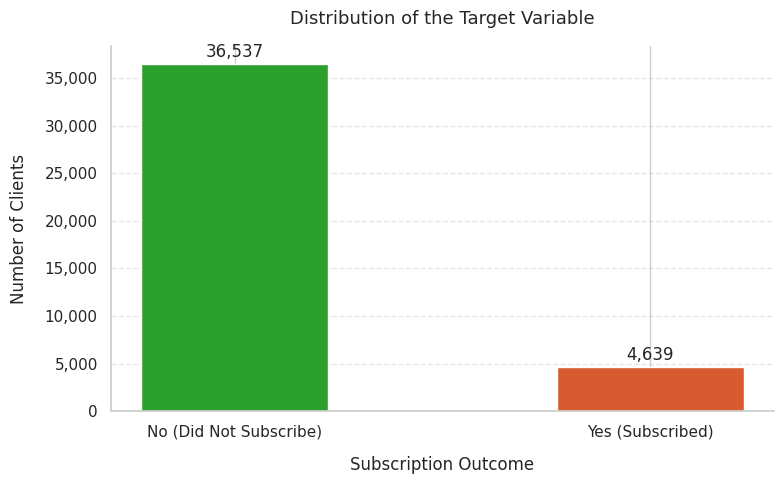

In [71]:
counts = marketing[TARGET].value_counts()
pcts   = marketing[TARGET].value_counts(normalize=True) * 100

print(pd.DataFrame({'Count': counts, 'Percentage (%)': pcts.round(2)}))

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    ['No (Did Not Subscribe)', 'Yes (Subscribed)'],
    counts.values,
    color=PALETTE,
    width=0.45,
    edgecolor='white'
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 280,
        f'{bar.get_height():,}',
        ha='center', va='bottom', fontsize=12
    )

plt.title('Distribution of the Target Variable', pad=16, fontsize=13)
plt.xlabel('Subscription Outcome', labelpad=12)
plt.ylabel('Number of Clients', labelpad=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine(top=True, right=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_3_1_class_distribution.png', dpi=300)
plt.show()

## 3.10 Distributions of the numerical features

duration, campaign and previous are heavily right skewed. pdays is one
spike at 999, confirming the flag conversion in Part 2. The economic
indicators hold one value per campaign period, so they describe when a
client was called, not who the client is.

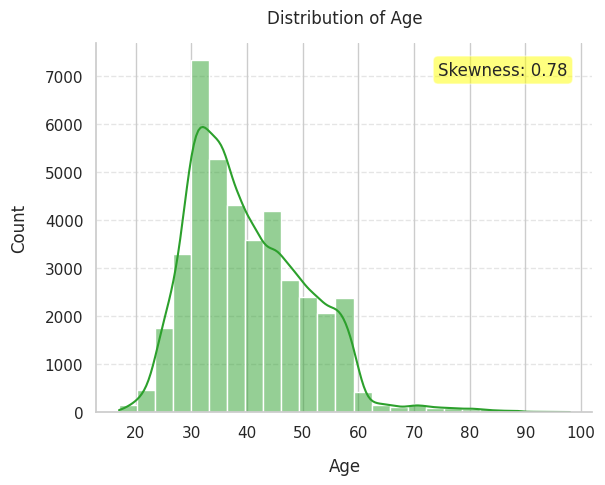

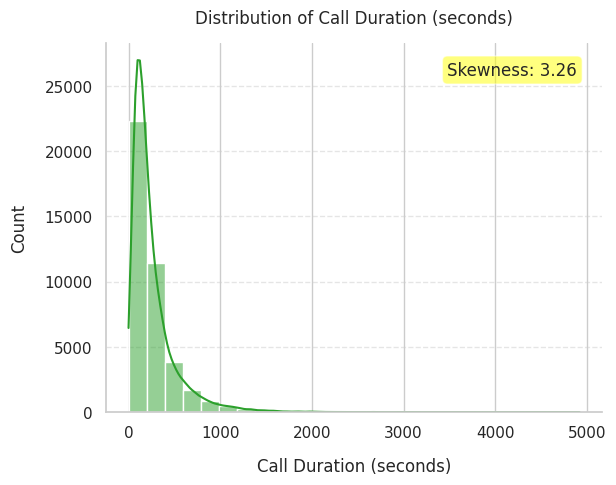

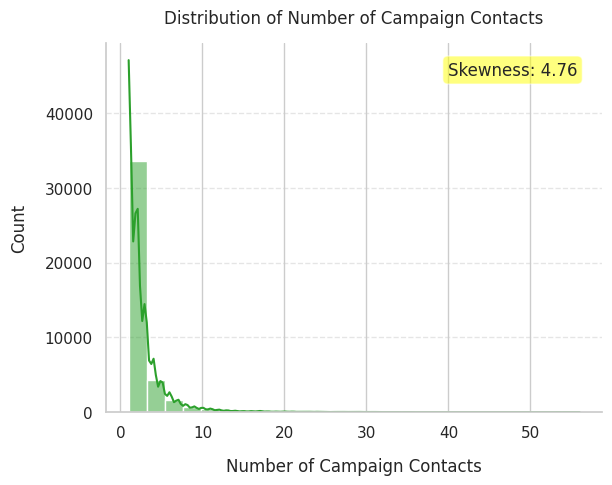

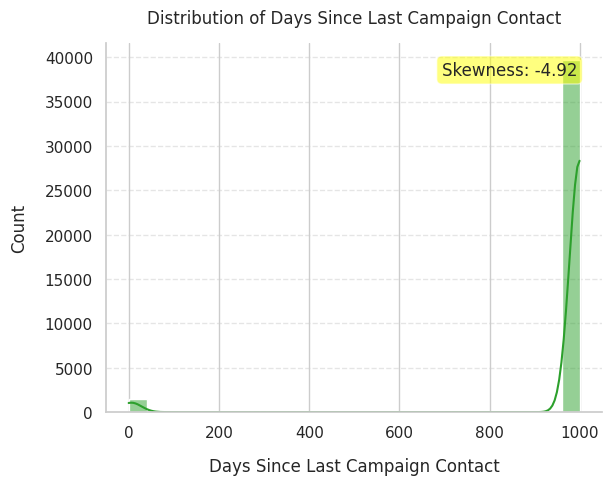

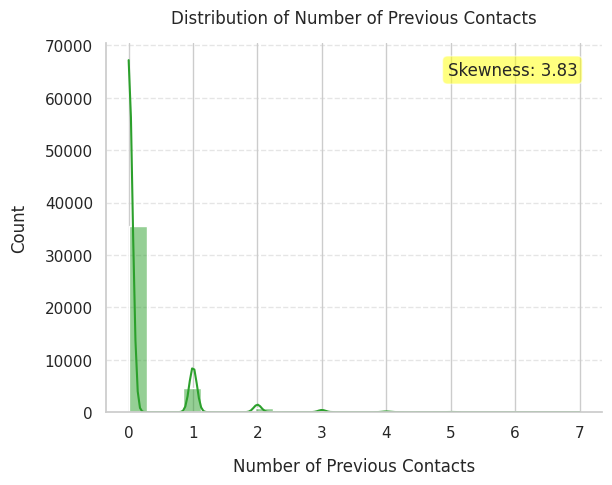

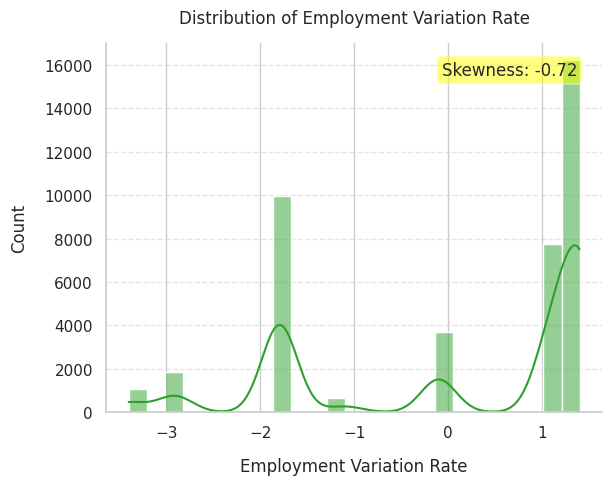

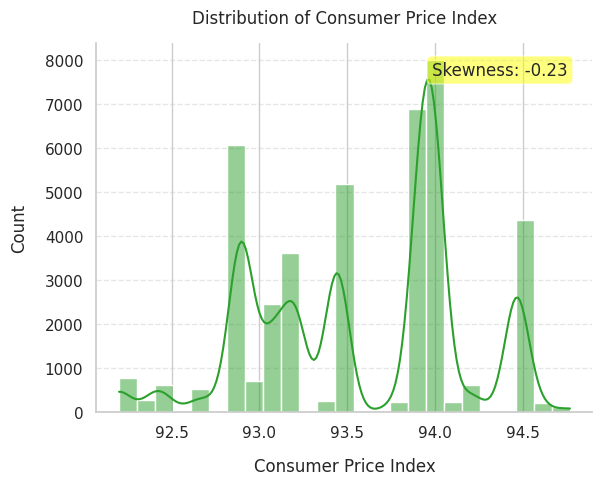

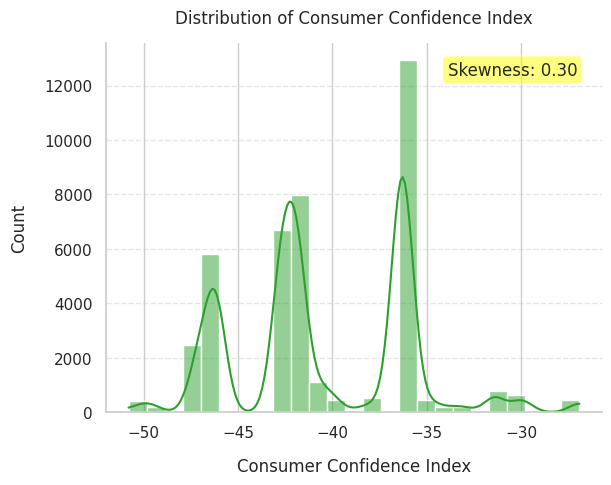

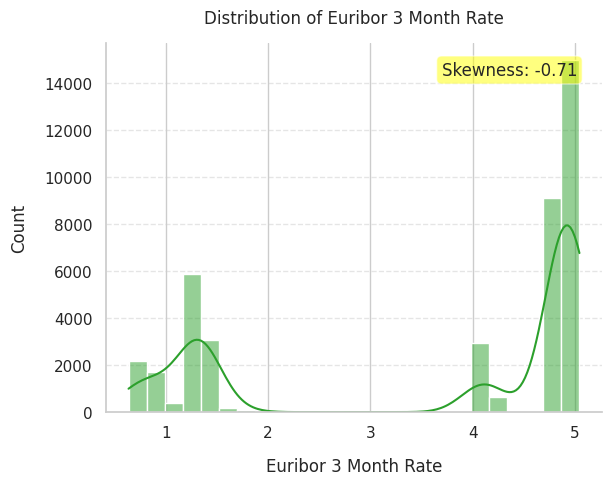

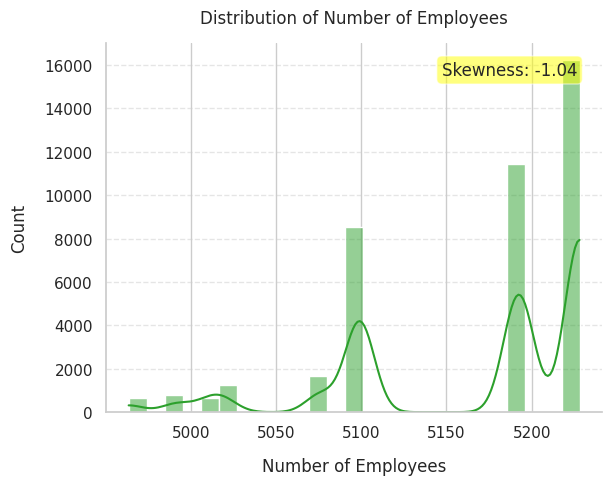

In [72]:
feature_names = {
    'age'            : 'Age',
    'duration'       : 'Call Duration (seconds)',
    'campaign'       : 'Number of Campaign Contacts',
    'pdays'          : 'Days Since Last Campaign Contact',
    'previous'       : 'Number of Previous Contacts',
    'emp.var.rate'   : 'Employment Variation Rate',
    'cons.price.idx' : 'Consumer Price Index',
    'cons.conf.idx'  : 'Consumer Confidence Index',
    'euribor3m'      : 'Euribor 3 Month Rate',
    'nr.employed'    : 'Number of Employees'
}

for col in num_features:
    fig, ax = plt.subplots()
    sns.histplot(marketing[col], kde=True, bins=25, color=COLOUR_NO)
    plt.title(f'Distribution of {feature_names.get(col, col)}', pad=14)
    plt.text(
        0.95, 0.95, f'Skewness: {marketing[col].skew():.2f}',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5)
    )
    plt.xlabel(feature_names.get(col, col), labelpad=12)
    plt.ylabel('Count', labelpad=12)
    sns.despine(top=True, right=True)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.savefig(f'dist_{col.replace(".", "_")}.png', dpi=300)
    plt.show()

## 3.11 Distributions of the categorical features

admin. is the largest job group and university degree the largest education
level. May holds around a third of all contacts, December almost none.
default is binary in practice, a handful of yes values, everyone else no
or unknown.

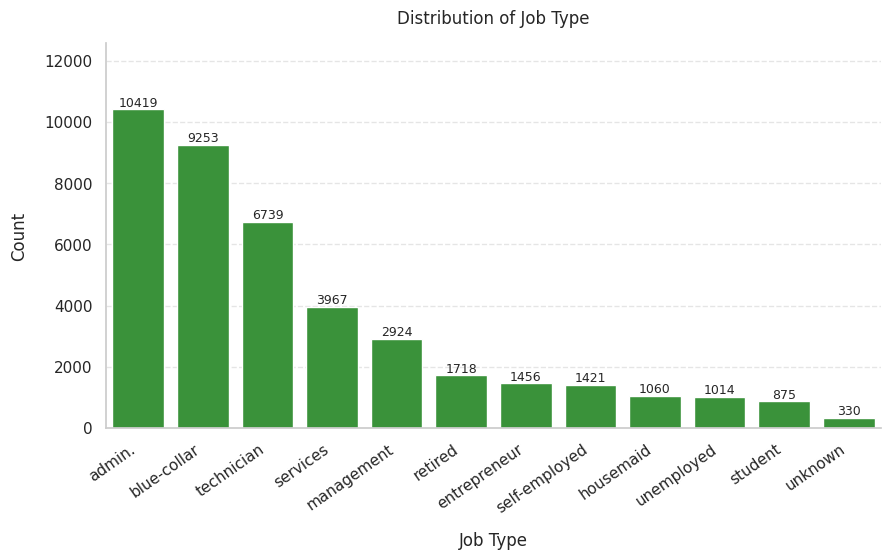

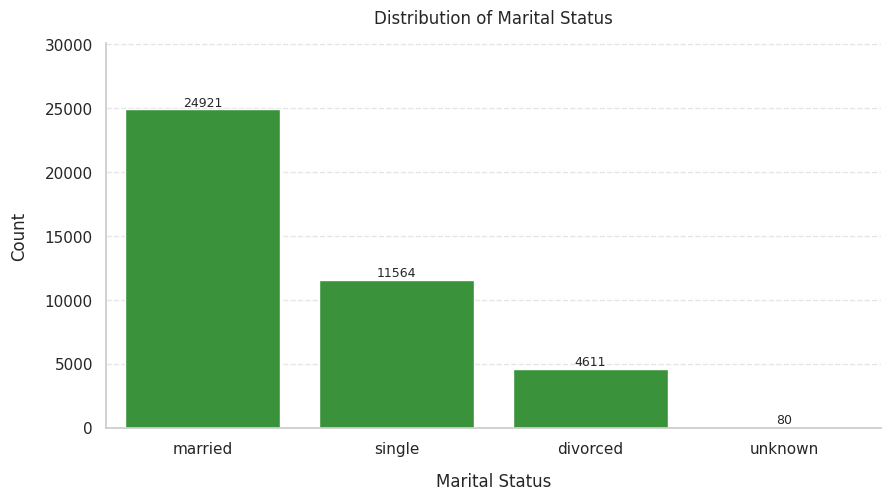

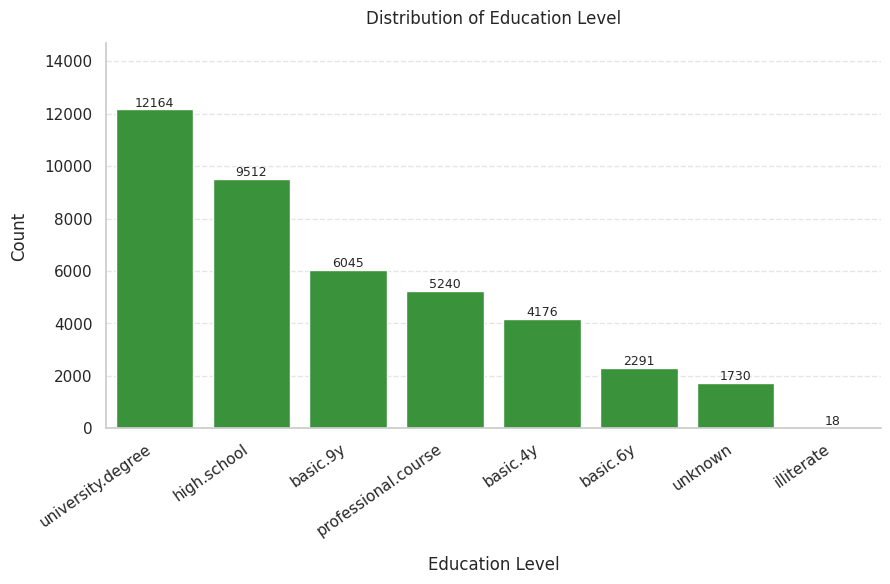

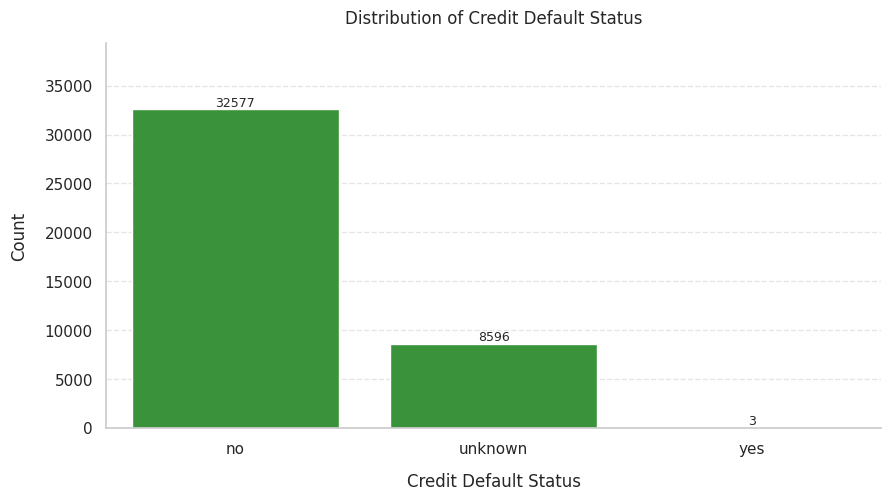

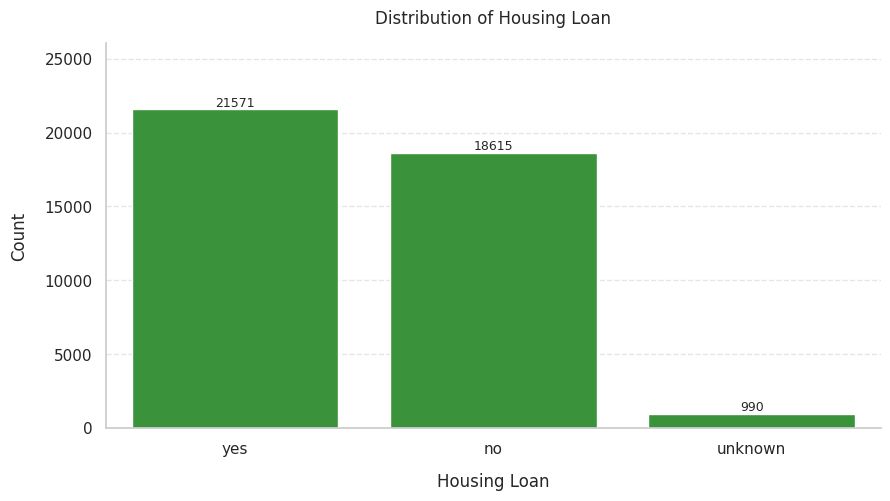

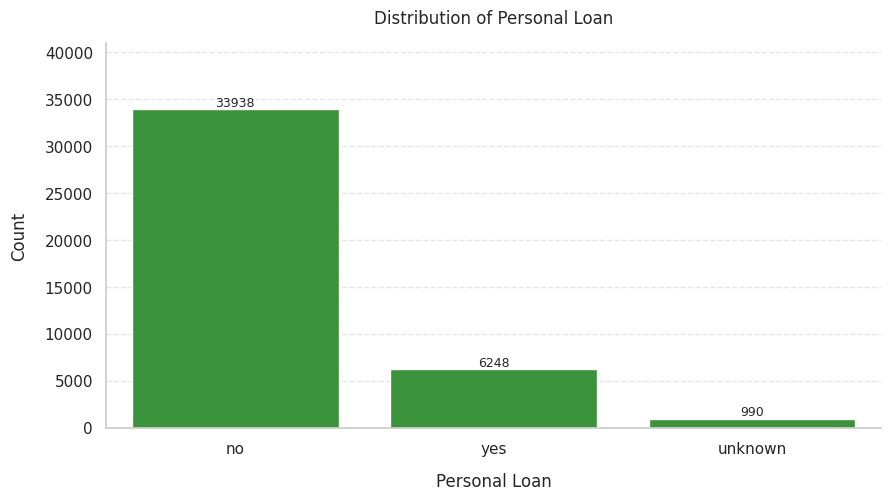

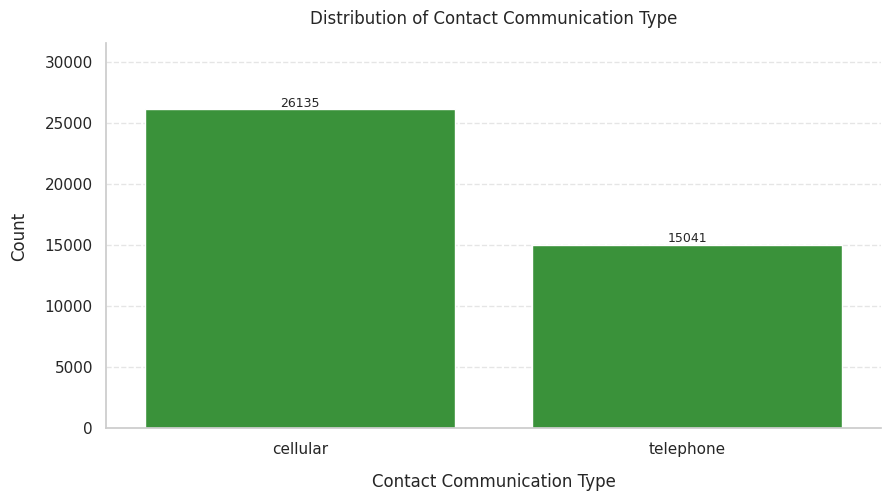

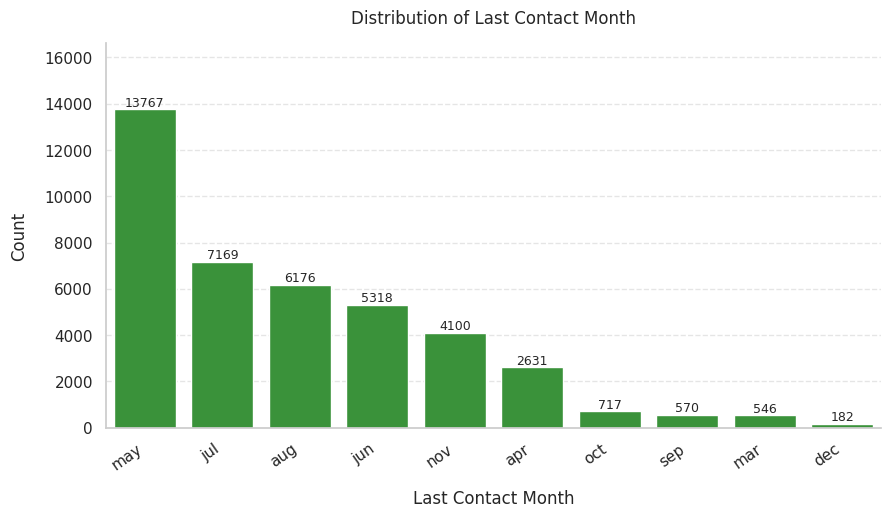

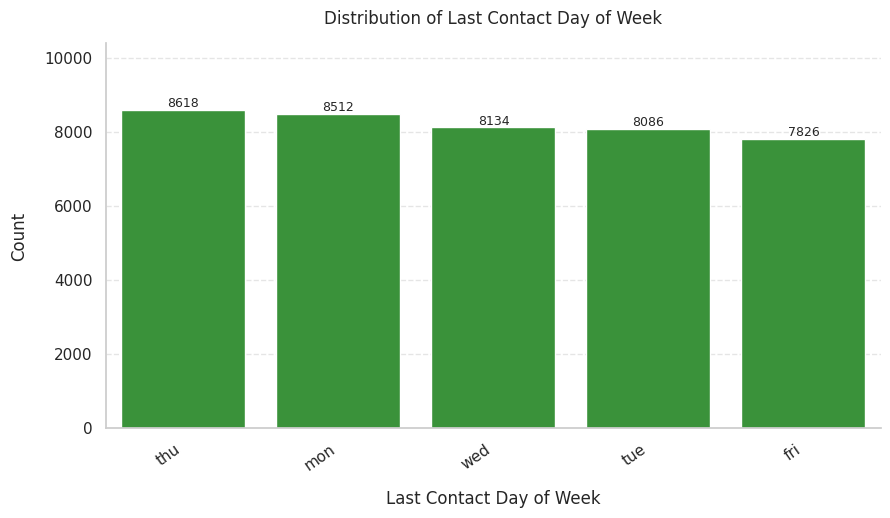

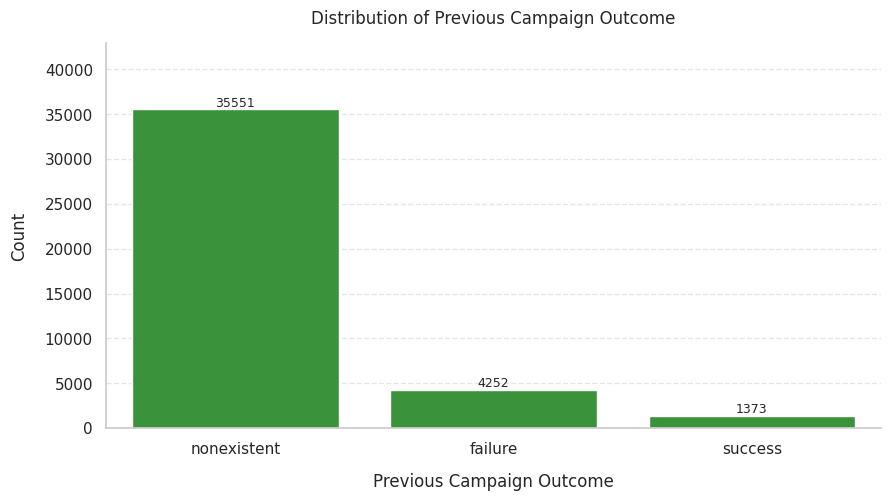

In [73]:
cat_feature_names = {
    'job'         : 'Job Type',
    'marital'     : 'Marital Status',
    'education'   : 'Education Level',
    'default'     : 'Credit Default Status',
    'housing'     : 'Housing Loan',
    'loan'        : 'Personal Loan',
    'contact'     : 'Contact Communication Type',
    'month'       : 'Last Contact Month',
    'day_of_week' : 'Last Contact Day of Week',
    'poutcome'    : 'Previous Campaign Outcome'
}

for col in cat_features:
    fig, ax = plt.subplots(figsize=(10, 5))
    order = marketing[col].value_counts().index
    sns.countplot(data=marketing, x=col, order=order, color=COLOUR_NO, ax=ax)

    if marketing[col].nunique() > 4:
        plt.xticks(rotation=35, ha='right')

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9)

    plt.title(f'Distribution of {cat_feature_names.get(col, col)}', pad=14)
    plt.xlabel(cat_feature_names.get(col, col), labelpad=12)
    plt.ylabel('Count', labelpad=12)
    plt.ylim(0, ax.get_ylim()[1] * 1.15)
    sns.despine(top=True, right=True)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.savefig(f'count_{col.replace(".", "_")}.png', dpi=300)
    plt.show()

## 3.12 Subscription rate by category

Where the bank called and where calls worked disagree. Prior campaign
success converts at around 65%, the strongest single signal. Students and
retired clients lead the job rates, blue collar sits last. Cellular
converts at roughly three times landline. May has the most calls and one
of the worst rates. day_of_week is excluded, its rates are flat.

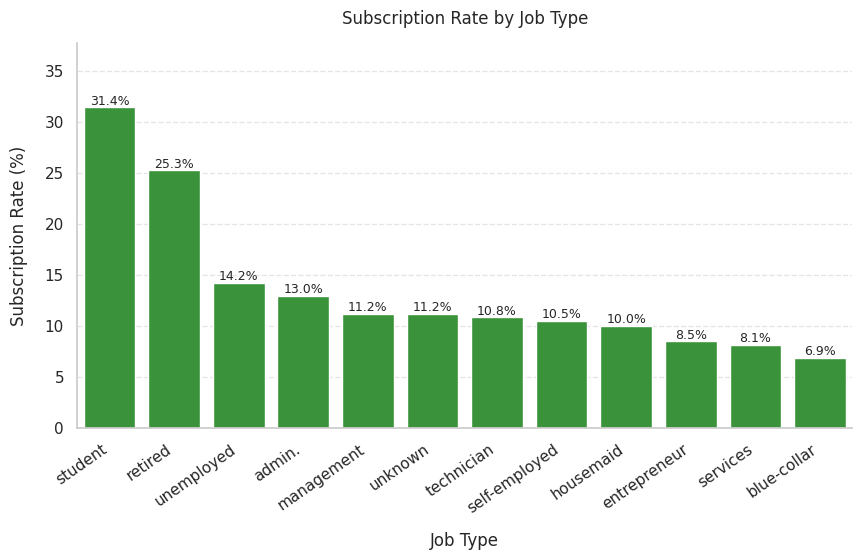

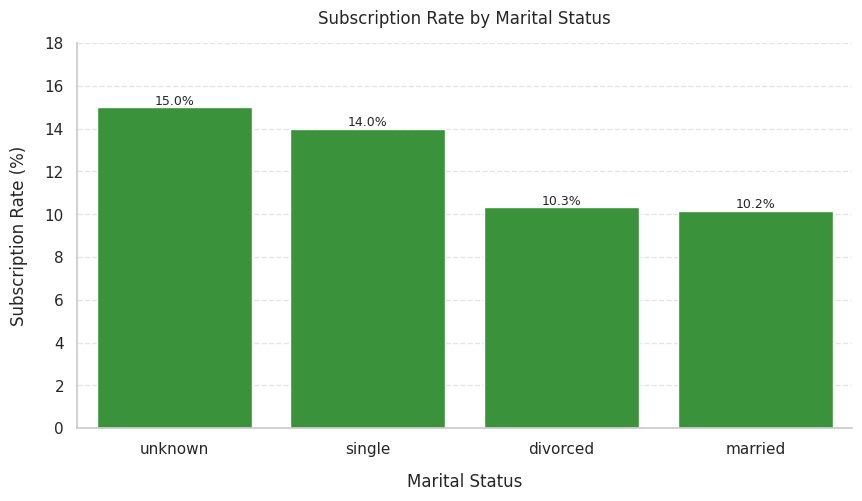

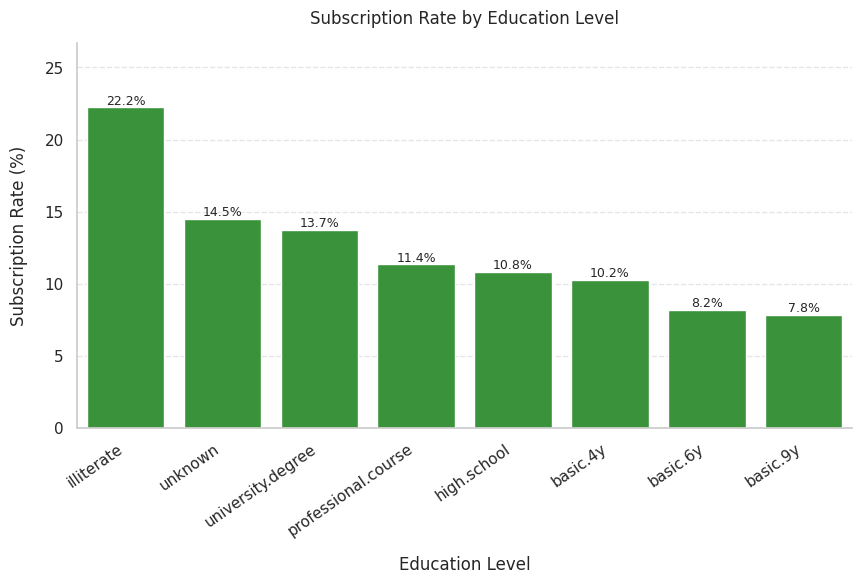

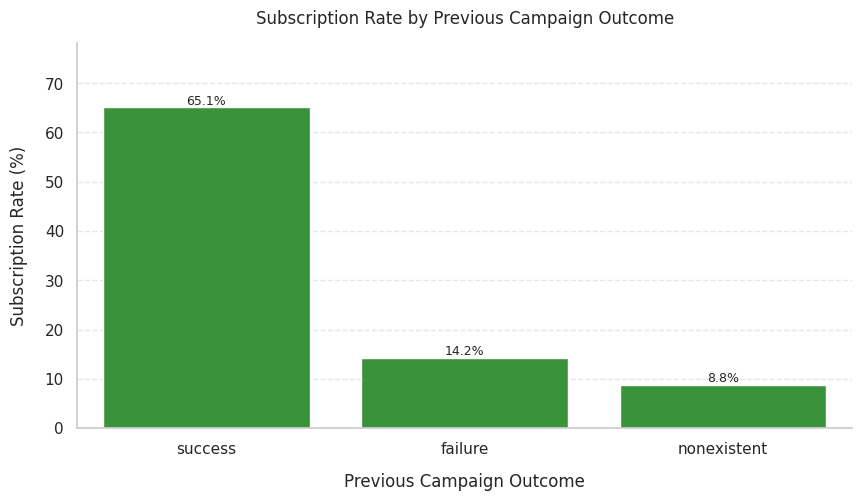

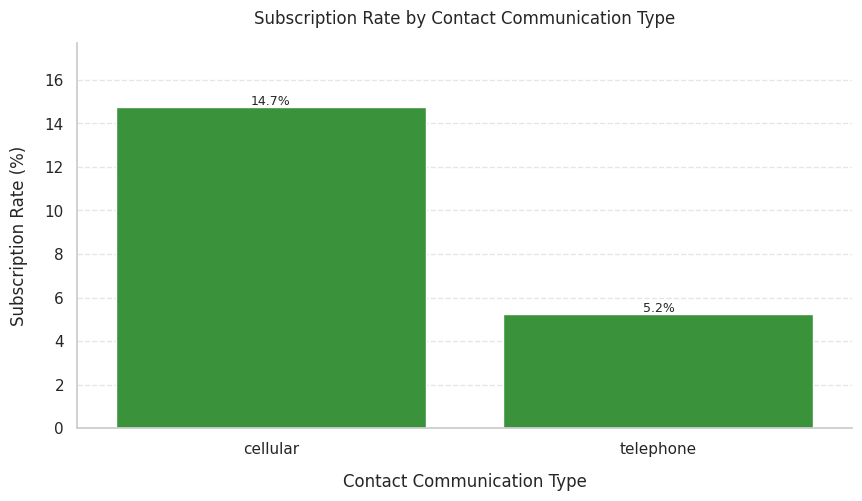

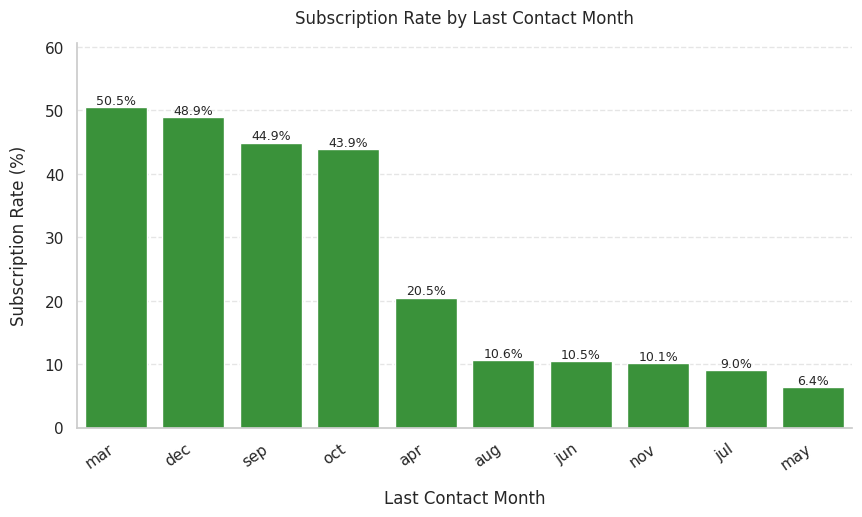

In [74]:
key_cats = ['job', 'marital', 'education', 'poutcome', 'contact', 'month']

for col in key_cats:
    fig, ax = plt.subplots(figsize=(10, 5))

    rate = (
        marketing.groupby(col)[TARGET]
        .apply(lambda x: (x == 'yes').mean() * 100)
        .sort_values(ascending=False)
        .reset_index()
    )
    rate.columns = [col, 'Subscription Rate (%)']

    sns.barplot(data=rate, x=col, y='Subscription Rate (%)',
                color=COLOUR_NO, ax=ax)

    if marketing[col].nunique() > 4:
        plt.xticks(rotation=35, ha='right')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9)

    plt.title(f'Subscription Rate by {cat_feature_names.get(col, col)}', pad=14)
    plt.xlabel(cat_feature_names.get(col, col), labelpad=12)
    plt.ylabel('Subscription Rate (%)', labelpad=12)
    plt.ylim(0, rate['Subscription Rate (%)'].max() * 1.2)
    sns.despine(top=True, right=True)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.savefig(f'rate_{col.replace(".", "_")}.png', dpi=300)
    plt.show()

## 3.13 Age by subscription outcome

Both classes centre on working age. Subscribers carry clear extra mass
past 60, matching the retired lead in 3.12. This tail is also why high
ages are not trimmed as outliers, it is where the customers are.

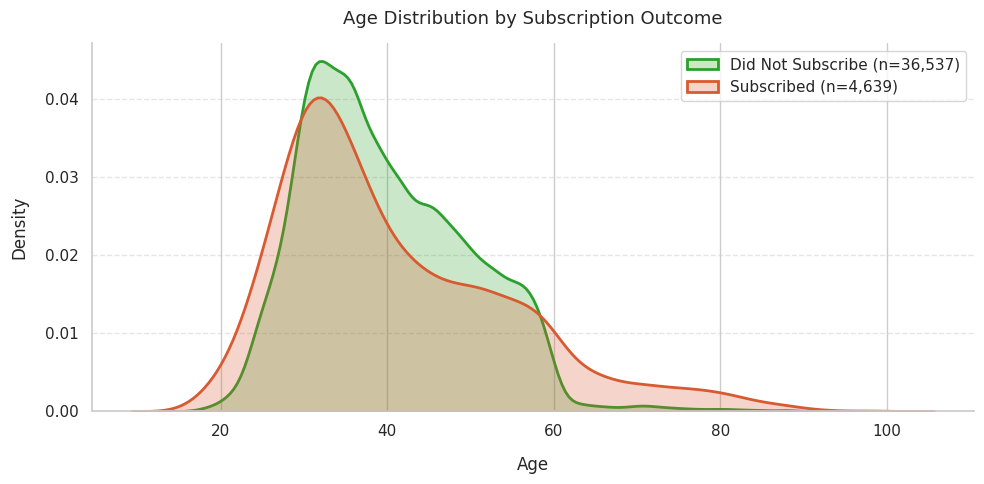

In [75]:
fig, ax = plt.subplots(figsize=(10, 5))

for outcome, colour, label in [
    ('no',  COLOUR_NO,  f'Did Not Subscribe (n={counts["no"]:,})'),
    ('yes', COLOUR_YES, f'Subscribed (n={counts["yes"]:,})')
]:
    subset = marketing[marketing[TARGET] == outcome]['age']
    sns.kdeplot(subset, ax=ax, color=colour, label=label,
                linewidth=2, fill=True, alpha=0.25)

plt.title('Age Distribution by Subscription Outcome', pad=14, fontsize=13)
plt.xlabel('Age', labelpad=12)
plt.ylabel('Density', labelpad=12)
plt.legend(fontsize=11)
sns.despine(top=True, right=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_age_by_subscription.png', dpi=300)
plt.show()

## 3.14 Correlation among the numerical features

emp.var.rate, euribor3m and nr.employed correlate above 0.9, all three
track the same economic cycle. pdays and previous correlate negatively for
the mechanical reason in 3.6. All features are kept, multicollinearity
distorts Logistic Regression coefficients but not predictions, and the
tree ensembles ignore it.

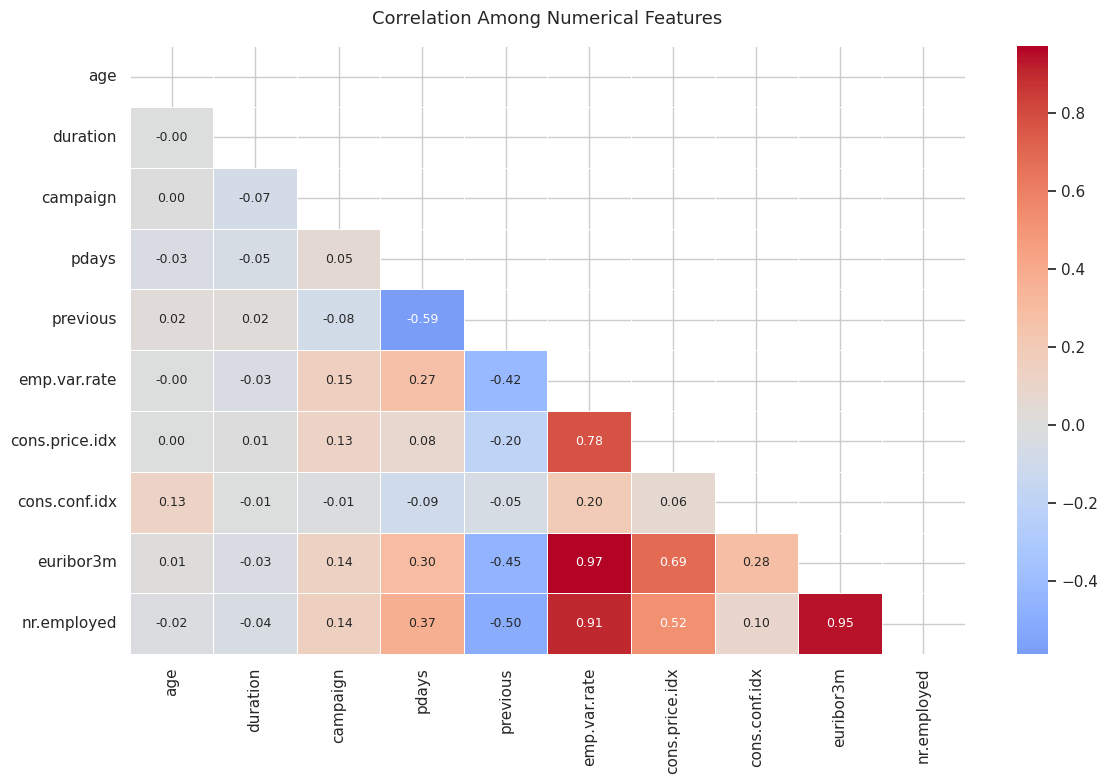

Pairs with |r| > 0.70:
  cons.price.idx  and  emp.var.rate  :  r = 0.775
  euribor3m  and  emp.var.rate  :  r = 0.972
  nr.employed  and  emp.var.rate  :  r = 0.907
  nr.employed  and  euribor3m  :  r = 0.945


In [76]:
fig, ax = plt.subplots(figsize=(12, 8))

corr_matrix = marketing[num_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            ax=ax, annot_kws={'size': 9})

plt.title('Correlation Among Numerical Features', pad=16, fontsize=13)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=300)
plt.show()

strong_pairs = [
    (corr_matrix.columns[i], corr_matrix.columns[j],
     round(corr_matrix.iloc[i, j], 3))
    for i in range(len(corr_matrix.columns))
    for j in range(i)
    if abs(corr_matrix.iloc[i, j]) > 0.70
]

print('Pairs with |r| > 0.70:')
for a, b, r in strong_pairs:
    print(f'  {a}  and  {b}  :  r = {r}')

## 3.14 Correlation among the numerical features

emp.var.rate, euribor3m and nr.employed correlate above 0.9, all three
track the same economic cycle. pdays and previous correlate negatively for
the mechanical reason in 3.6. All features are kept, multicollinearity
distorts Logistic Regression coefficients but not predictions, and the
tree ensembles ignore it.

In [ ]:
outlier_results = {}

for col in num_features:
    q1, q3 = marketing[col].quantile([0.25, 0.75])
    iqr    = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count  = ((marketing[col] < lower) | (marketing[col] > upper)).sum()

    outlier_results[col] = {
        'Lower Bound'  : round(lower, 2),
        'Upper Bound'  : round(upper, 2),
        'Flagged Count': count,
        'Flagged (%)'  : round(count / len(marketing) * 100, 2)
    }

outlier_df = pd.DataFrame(outlier_results).T
outlier_df = outlier_df[outlier_df['Flagged Count'] > 0]

print(outlier_df.to_string())
print(f'\nTotal flagged values: {outlier_df["Flagged Count"].sum():,.0f}')
print('All records are retained.')

## 3.15 Outlier detection

IQR is used instead of z scores because the features are skewed. Flagged
values are counted and kept. They are genuine customers, an 88 year old
retiree or a 40 minute call, exactly the clients the bank wants to find.
Robustness is handled by the scaler and the tree models, not by deletion.

In [77]:
outlier_results = {}

for col in num_features:
    q1, q3 = marketing[col].quantile([0.25, 0.75])
    iqr    = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count  = ((marketing[col] < lower) | (marketing[col] > upper)).sum()

    outlier_results[col] = {
        'Lower Bound'  : round(lower, 2),
        'Upper Bound'  : round(upper, 2),
        'Flagged Count': count,
        'Flagged (%)'  : round(count / len(marketing) * 100, 2)
    }

outlier_df = pd.DataFrame(outlier_results).T
outlier_df = outlier_df[outlier_df['Flagged Count'] > 0]

print(outlier_df.to_string())
print(f'\nTotal flagged values: {outlier_df["Flagged Count"].sum():,.0f}')
print('All records are retained.')

               Lower Bound  Upper Bound  Flagged Count  Flagged (%)
age                   9.50        69.50         468.00         1.14
duration           -223.50       644.50        2963.00         7.20
campaign             -2.00         6.00        2406.00         5.84
pdays               999.00       999.00        1515.00         3.68
previous              0.00         0.00        5625.00        13.66
cons.conf.idx       -52.15       -26.95         446.00         1.08

Total flagged values: 13,423
All records are retained.


In [ ]:
print('Outlier Detection Summary — IQR Method  (Table 3.3)')
print('=' * 62)

outlier_results = {}

for col in num_features:
    Q1    = marketing[col].quantile(0.25)
    Q3    = marketing[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((marketing[col] < lower) | (marketing[col] > upper)).sum()
    pct   = round(count / len(marketing) * 100, 2)

    outlier_results[col] = {
        'Lower Bound'   : round(lower, 2),
        'Upper Bound'   : round(upper, 2),
        'Outlier Count' : count,
        'Outlier (%)'   : pct}

outlier_df = pd.DataFrame(outlier_results).T
outlier_df = outlier_df[outlier_df['Outlier Count'] > 0]

print(outlier_df.to_string())
print(f'\nTotal outlier entries: {outlier_df["Outlier Count"].sum():,.0f}')

Outlier Detection Summary — IQR Method  (Table 3.3)
               Lower Bound  Upper Bound  Outlier Count  Outlier (%)
age                   9.50        69.50         468.00         1.14
duration           -223.50       644.50        2963.00         7.20
campaign             -2.00         6.00        2406.00         5.84
pdays               999.00       999.00        1515.00         3.68
previous              0.00         0.00        5625.00        13.66
cons.conf.idx       -52.15       -26.95         446.00         1.08

Total outlier entries: 13,423


## 3.16 Dataset state at the end of Part 1

Every number here is computed from the DataFrame, so this cell cannot
disagree with the data. It feeds Table 3.2 of the report, and Part 2
starts from this state.

In [78]:
state = {
    'Total records'                 : f'{len(marketing):,}',
    'Features (excluding target)'   : len(marketing.columns) - 1,
    'Numerical features'            : len(num_features),
    'Categorical features'          : len(cat_features),
    'NaN values'                    : marketing.isnull().sum().sum(),
    'Columns containing unknown'    : int((marketing == 'unknown').any().sum()),
    'Rows with pdays = 999'         : f'{(marketing["pdays"] == 999).sum():,}',
    'Class no'                      : f'{(marketing[TARGET] == "no").sum():,}'
                                      f'  ({(marketing[TARGET] == "no").mean()*100:.1f}%)',
    'Class yes'                     : f'{(marketing[TARGET] == "yes").sum():,}'
                                      f'  ({(marketing[TARGET] == "yes").mean()*100:.1f}%)'
}

print('Dataset state, end of Part 1')
print('=' * 50)
for k, v in state.items():
    print(f'  {k:30} : {v}')

Dataset state, end of Part 1
  Total records                  : 41,176
  Features (excluding target)    : 20
  Numerical features             : 10
  Categorical features           : 10
  NaN values                     : 0
  Columns containing unknown     : 6
  Rows with pdays = 999          : 39,661
  Class no                       : 36,537  (88.7%)
  Class yes                      : 4,639  (11.3%)


---
# Part 2: Data Preprocessing and Feature Engineering

This section covers **Section 3.3** of the final report:
- Removing outliers detected in Part 1
- Transforming the pdays column into two meaningful features
- Engineering new features from existing ones
- Classifying features for the ColumnTransformer
- Splitting the data into training and test sets
- Building the full imblearn Pipeline with SMOTE
- Confirming the final dataset state before modelling

## Cell 19 — Install Additional Libraries



In [ ]:
# Install imbalanced-learn for SMOTE and the imblearn pipeline 19

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve,
    matthews_corrcoef, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier



## Cell 20 — Remove Outliers (IQR Method)

Using the IQR boundaries identified in Cell 17 of Part 1. Only features with meaningful outliers are included. `pdays` and `previous` are excluded here because `pdays` is being transformed separately in Cell 21, and the IQR for `previous` (Q1=Q3=0) would incorrectly flag all non-zero values.

In [ ]:
# Record the row count before removal for the report 20
rows_before = len(marketing)

# Only apply IQR outlier removal to features where it makes genuine sense.
# clients with any prior contact  those are important records.
outlier_cols = ['age', 'duration', 'campaign', 'cons.conf.idx']

def remove_outliers_iqr(df, cols):
    mask = pd.Series(True, index=df.index)
    for col in cols:
        Q1    = df[col].quantile(0.25)
        Q3    = df[col].quantile(0.75)
        IQR   = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask  = mask & (df[col] >= lower) & (df[col] <= upper)
    return df[mask].copy()

marketing = remove_outliers_iqr(marketing, outlier_cols)
marketing.reset_index(drop=True, inplace=True)

rows_after   = len(marketing)
rows_removed = rows_before - rows_after

print(f'Rows before outlier removal : {rows_before:,}')
print(f'Rows removed                : {rows_removed:,}')
print(f'Rows after outlier removal  : {rows_after:,}')
print(f'\nDataFrame shape: {marketing.shape}')

Rows before outlier removal : 41,176
Rows removed                : 6,011
Rows after outlier removal  : 35,165

DataFrame shape: (35165, 21)


## Cell 21 — Transform the pdays Column

As identified in Cell 8 of Part 1, `pdays = 999` means the last contact date was not recorded — not that the client was never contacted. Two new features replace the original column to capture both pieces of information without feeding 999 as a real number into the models.

In [ ]:

    # Step 1: Create a binary flag to indicate if a previous contact exists.
    # 1 = Returning Client (record exists), 0 = New Lead (pdays was 999)
    marketing['is_returning_client'] = (marketing['pdays'] != 999).astype(int)

    # Step 2: Create a numeric column for the number of days.
    # We replace 999 with -1 to group 'New Leads' together and avoid model bias.
    marketing['days_since_last_contact'] = marketing['pdays'].replace(999, -1)

    # Step 3: Remove the original pdays column to keep the dataset clean
    marketing.drop('pdays', axis=1, inplace=True)

print('\n FEATURE TRANSFORMATION: PDAYS')

returning_count = marketing['is_returning_client'].sum()
new_lead_count  = (marketing['is_returning_client'] == 0).sum()

print(f'RETURNING CLIENTS (Had history) : {returning_count:,}')
print(f'NEW LEADS (No prior contact)    : {new_lead_count:,}')
print(f'\nUpdated DataFrame shape: {marketing.shape}')


 FEATURE TRANSFORMATION: PDAYS
RETURNING CLIENTS (Had history) : 1,206
NEW LEADS (No prior contact)    : 33,959

Updated DataFrame shape: (35165, 22)


## Cell 22 — Feature Engineering

Creating two new features that capture meaningful patterns not directly expressed by any individual column. Each one is justified by domain knowledge about how marketing campaigns work.

In [ ]:
# Feature 1: contact_intensity
# Total number of times a client has been contacted across both
# the current campaign and any previous campaigns.
# A client contacted many times across campaigns is either very
# resistant or very engaged the model can learn which.
marketing['contact_intensity'] = marketing['campaign'] + marketing['previous']

# Feature 2: long_call
# Binary flag indicating whether the last call lasted more than
# 5 minutes (300 seconds). Longer calls tend to indicate genuine
# client interest and are associated with higher subscription rates.
marketing['long_call'] = (marketing['duration'] > 300).astype(int)

print('New engineered features created:')
print(f"  contact_intensity — min: {marketing['contact_intensity'].min()}  "
      f"max: {marketing['contact_intensity'].max()}  "
      f"mean: {marketing['contact_intensity'].mean():.2f}")
print(f"  long_call         — 0s: {(marketing['long_call']==0).sum():,}  "
      f"1s: {(marketing['long_call']==1).sum():,}")
print(f'\nDataFrame shape: {marketing.shape}')

New engineered features created:
  contact_intensity — min: 1  max: 10  mean: 2.22
  long_call         — 0s: 27,440  1s: 7,725

DataFrame shape: (35165, 24)


## Cell 23 — Classify Features for the ColumnTransformer

The ColumnTransformer applies different transformations to different column types. Before building it, every feature must be assigned to the correct group. Education and month are treated as ordinal because their categories have a natural order. All other categorical columns are treated as nominal.

In [ ]:
# Separate features from the target variable
X = marketing.drop(TARGET, axis=1)
y = marketing[TARGET]

# Convert target to binary — 1 for subscribed, 0 for not subscribed
y = (y == 'yes').astype(int)

# Numerical features — scaled with RobustScaler
# RobustScaler uses median and IQR so it is less sensitive to
# any remaining outliers than StandardScaler
num_cols = [
    'age', 'duration', 'campaign', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed',
    'is_returning_client', 'days_since_last_contact',
    'contact_intensity', 'long_call']

# Ordinal categorical — categories have a meaningful order
# Education: from least to most qualified
# Month: calendar order
ord_cols = ['education', 'month']

education_order = [
    'illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
    'high.school', 'professional.course', 'university.degree', 'unknown']

month_order = [
    'jan', 'feb', 'mar', 'apr', 'may', 'jun',
    'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# Nominal categorical — no natural order, one-hot encoded
nom_cols = [
    'job', 'marital', 'default', 'housing',
    'loan', 'contact', 'day_of_week', 'poutcome']

print('Feature classification for ColumnTransformer')
print('=' * 55)
print(f'Numerical   ({len(num_cols)}) : {num_cols}')
print(f'Ordinal     ({len(ord_cols)}) : {ord_cols}')
print(f'Nominal     ({len(nom_cols)}) : {nom_cols}')
print(f'\nTarget: {TARGET} (encoded as 1=yes, 0=no)')
print(f'\nX shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nClass distribution after encoding:')
print(y.value_counts())

Feature classification for ColumnTransformer
Numerical   (13) : ['age', 'duration', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'is_returning_client', 'days_since_last_contact', 'contact_intensity', 'long_call']
Ordinal     (2) : ['education', 'month']
Nominal     (8) : ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'day_of_week', 'poutcome']

Target: subscribed (encoded as 1=yes, 0=no)

X shape: (35165, 23)
y shape: (35165,)

Class distribution after encoding:
subscribed
0    32435
1     2730
Name: count, dtype: int64


## Cell 24 — Split Data into Training and Test Sets

Stratified splitting preserves the 88.7% / 11.3% class ratio in both sets. The test set is held completely aside and never seen by the model during training or hyperparameter tuning. `random_state=42` ensures reproducibility.

In [ ]:
#Split Data into Training and Test Sets

# X and y defined here so this cell runs independently
# even if Cell 23 was not run in the current session
X = marketing.drop(TARGET, axis=1)
y = marketing[TARGET]

# Convert target to binary — 1 for subscribed, 0 for not subscribed
y = (y == 'yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)   # preserves class ratio in both sets

print('Data split complete.')
print(f'Training set   : {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set       : {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X)*100:.1f}%)')
print()
print('Class distribution in training set:')
print(y_train.value_counts())
print()
print('Class distribution in test set:')
print(y_test.value_counts())

Data split complete.
Training set   : 28,132 rows  (80.0%)
Test set       : 7,033 rows  (20.0%)

Class distribution in training set:
subscribed
0    25948
1     2184
Name: count, dtype: int64

Class distribution in test set:
subscribed
0    6487
1     546
Name: count, dtype: int64


## Cell 25 — Build the ColumnTransformer

The ColumnTransformer applies the correct transformation to each feature group simultaneously. Using a transformer ensures the same fitted parameters from training are applied consistently to the test set.

In [ ]:
#Build the ColumnTransformer
# Now that prev_contact_unknown_days uses -1 instead of NaN,
# RobustScaler handles all numerical columns without any imputer needed.

from sklearn.pipeline import Pipeline as SklearnPipeline

preprocessor = ColumnTransformer(
    transformers=[

        # Numerical — RobustScaler scales using median and IQR
        ('num',
         RobustScaler(),
         num_cols),

        # Ordinal — preserves natural order of education and month
        ('ord_encoder',
         OrdinalEncoder(
             categories=[education_order, month_order],
             handle_unknown='use_encoded_value',
             unknown_value=-1 ),

         ord_cols),

        # Nominal — one-hot encodes all remaining categorical features
        ('onehot',
         OneHotEncoder(
             handle_unknown='ignore',
             sparse_output=False),
         nom_cols)],

    remainder='passthrough')


print('ColumnTransformer built successfully.')
print('Transformations:')
print(f'  RobustScaler   → {len(num_cols)} numerical features')
print(f'  OrdinalEncoder → {len(ord_cols)} ordinal features')
print(f'  OneHotEncoder  → {len(nom_cols)} nominal features')
print()


ColumnTransformer built successfully.
Transformations:
  RobustScaler   → 13 numerical features
  OrdinalEncoder → 2 ordinal features
  OneHotEncoder  → 8 nominal features



## Cell 26 — Build the imblearn Pipeline

The pipeline chains the ColumnTransformer and SMOTE together in the correct order. Critically, SMOTE sits inside the pipeline rather than being applied before splitting. This ensures synthetic samples are only generated from the training data and the test set remains entirely unseen and unmodified preventing data leakage.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        # Numerical — RobustScaler scales using median and IQR
        ('num',
         RobustScaler(),
         num_cols),

        # Ordinal — preserves natural order of education and month
        ('ord_encoder',
         OrdinalEncoder(
             categories=[education_order, month_order],
             handle_unknown='use_encoded_value',
             unknown_value=-1 ),
         ord_cols),

        # Nominal — one-hot encodes all remaining categorical features
        ('onehot',
         OneHotEncoder(
             handle_unknown='ignore',
             sparse_output=False),
         nom_cols)
    ],
    remainder='passthrough')

print('ColumnTransformer built successfully.')
print('Transformations:')
print(f'  RobustScaler   → {len(num_cols)} numerical features')
print(f'  OrdinalEncoder → {len(ord_cols)} ordinal features (education, month)')
print(f'  OneHotEncoder  → {len(nom_cols)} nominal features')

ColumnTransformer built successfully.
Transformations:
  RobustScaler   → 13 numerical features
  OrdinalEncoder → 2 ordinal features (education, month)
  OneHotEncoder  → 8 nominal features


## Cell 27 — Define the Models

All the classifiers are defined in a single dictionary. The loop in Cell 28 iterates through them, swaps each one into the pipeline, trains it, and records the results. `random_state=42` is set on every model for full reproducibility.

In [ ]:

models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, max_iter=1000
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42
    ),
    'SVM': SVC(
        probability=True, random_state=42
    ),
    'XGBoost': XGBClassifier(
        random_state=42, eval_metric='logloss',
        verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        random_state=42, verbosity=-1
    )
}

print(f'{len(models)} models defined and ready for training:')
for name in models:
    print(f'  {name}')

6 models defined and ready for training:
  Logistic Regression
  Decision Tree
  Random Forest
  SVM
  XGBoost
  LightGBM


## Cell 28: Train All Models (Baseline)

Each model is trained using its default hyperparameters. This produces the **baseline results** the before-tuning row in the comparative results table. All predictions are made on the held-out test set.

In [ ]:
import time
from sklearn.linear_model import LogisticRegression # Needed for placeholder model

# Define the imblearn pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression())   # placeholder — replaced in Cell 27
])

# Storage for results
baseline_results = []
roc_results      = {}

print('Training all six models with default hyperparameters...')
print('=' * 65)

for name, model in models.items():

    # Swap the model into the pipeline
    pipeline.set_params(model=model)

    # Record training time
    start = time.time()
    pipeline.fit(X_train, y_train)
    train_time = round(time.time() - start, 2)

    # Make predictions on the unseen test set
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    # Calculate all metrics
    acc  = round(accuracy_score(y_test, y_pred), 4)
    prec = round(precision_score(y_test, y_pred), 4)
    rec  = round(recall_score(y_test, y_pred), 4)
    f1   = round(f1_score(y_test, y_pred), 4)
    auc  = round(roc_auc_score(y_test, y_proba), 4)
    mcc  = round(matthews_corrcoef(y_test, y_pred), 4)

    baseline_results.append({
        'Model'     : name,
        'Accuracy'  : acc,
        'Precision' : prec,
        'Recall'    : rec,
        'F1-Score'  : f1,
        'ROC-AUC'   : auc,
        'MCC'       : mcc,
        'Train Time (s)': train_time
    })

    # Store ROC data for plotting
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_results[name] = {
        'fpr': fpr, 'tpr': tpr, 'auc': auc
    }

    print(f'{name:<22} | F1: {f1}  AUC: {auc}  MCC: {mcc}  '
          f'Time: {train_time}s')

# Store as DataFrame
baseline_df = pd.DataFrame(baseline_results).set_index('Model')

print()
print('Baseline training complete.')
print()
print('Baseline Results Table (Table 4.1):')
print('=' * 65)
print(baseline_df.to_string())

Training all six models with default hyperparameters...
Logistic Regression    | F1: 0.4932  AUC: 0.9359  MCC: 0.4784  Time: 3.84s
Decision Tree          | F1: 0.4701  AUC: 0.7169  MCC: 0.4244  Time: 0.84s
Random Forest          | F1: 0.5372  AUC: 0.9483  MCC: 0.5151  Time: 8.65s
SVM                    | F1: 0.3799  AUC: 0.9313  MCC: 0.4092  Time: 131.14s
XGBoost                | F1: 0.5368  AUC: 0.9518  MCC: 0.5084  Time: 0.69s
LightGBM               | F1: 0.5582  AUC: 0.9571  MCC: 0.5334  Time: 0.72s

Baseline training complete.

Baseline Results Table (Table 4.1):
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  MCC  Train Time (s)
Model                                                                                   
Logistic Regression      0.94       0.65    0.40      0.49     0.94 0.48            3.84
Decision Tree            0.92       0.46    0.48      0.47     0.72 0.42            0.84
Random Forest            0.94       0.65    0.46      0.54     0.95 0.

## Cell 29: Baseline F1-Score Comparison Chart (Figure 4.2)

A bar chart comparing F1-Score across all six models before tuning. This goes directly into the report as Figure 4.2.

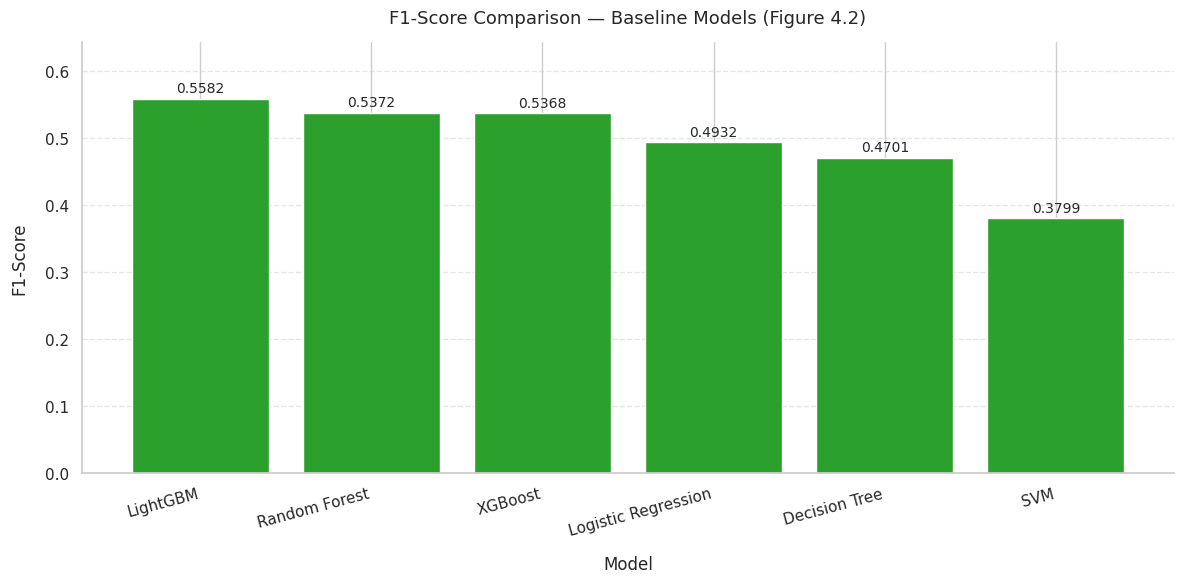

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

f1_scores = baseline_df['F1-Score'].sort_values(ascending=False)

bars = ax.bar(
    f1_scores.index,
    f1_scores.values,
    color=COLOUR_NO,
    edgecolor='white'
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.4f}',
        ha='center', va='bottom', fontsize=10
    )

plt.title('F1-Score Comparison — Baseline Models (Figure 4.2)', pad=14, fontsize=13)
plt.xlabel('Model', labelpad=12)
plt.ylabel('F1-Score', labelpad=12)
plt.ylim(0, f1_scores.max() * 1.15)
plt.xticks(rotation=15, ha='right')
sns.despine(top=True, right=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('fig_4_2_baseline_f1_comparison.png', dpi=300)
plt.show()

print('\n')

## Cell 30 — Baseline ROC-AUC Curves (Figure 4.1)

ROC curves for all six models plotted on the same axes for easy comparison. The diagonal dashed line represents random guessing (AUC = 0.50). This becomes Figure 4.1 in the report.

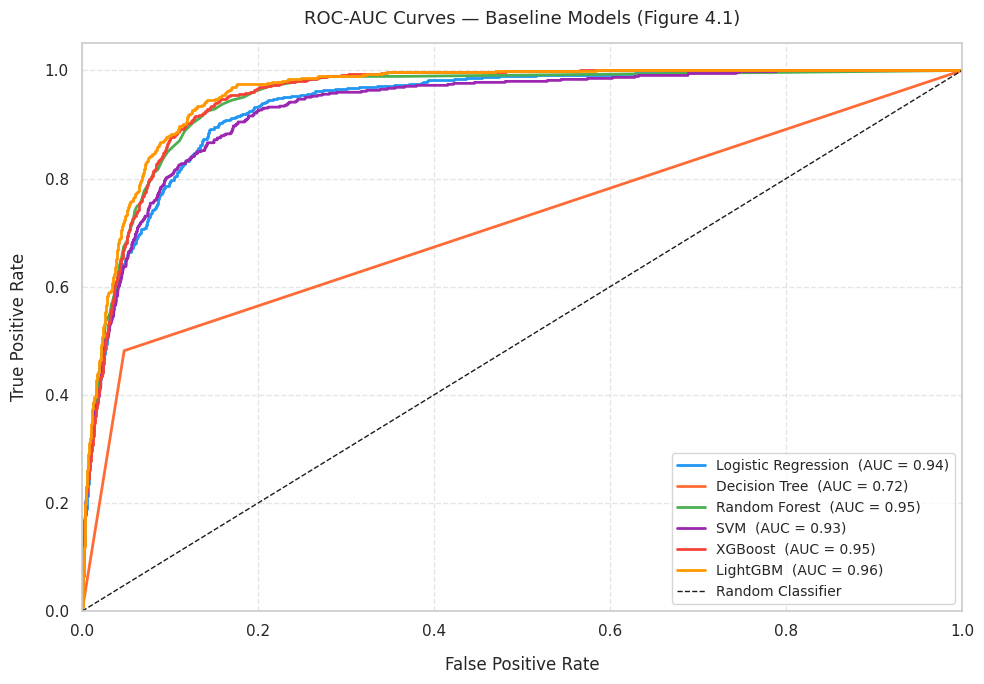

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

colours_roc = [
    '#2196F3', '#FF6B35', '#4CAF50',
    '#9C27B0', '#F44336', '#FF9800'
]

for (name, data), colour in zip(roc_results.items(), colours_roc):
    ax.plot(
        data['fpr'], data['tpr'],
        label=f"{name}  (AUC = {data['auc']:.2f})",
        color=colour, linewidth=2
    )

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

plt.title(
    'ROC-AUC Curves — Baseline Models (Figure 4.1)',
    pad=14, fontsize=13
)
plt.xlabel('False Positive Rate', labelpad=12)
plt.ylabel('True Positive Rate', labelpad=12)
plt.legend(loc='lower right', fontsize=10)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('fig_4_1_baseline_roc_curves.png', dpi=300)
plt.show()

print('\n')